In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer

# Data preparation

In [65]:
df = pd.read_csv('data/file_name.csv')

In [66]:
df

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,NaN,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,NaN,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,NaN,1.646268e+09
...,...,...,...,...,...,...,...,...,...
12849,Ron Paul’s Spirited Defense of WikiLeaks & Fre...,Conservative,2,em7rm,anarchocapitalism,http://www.deathandtaxesmag.com/40485/ron-paul...,1,NaN,1.292421e+09
12850,"“Anarcho-capitalism, in my opinion, is a doctr...",Conservative,2,ei98o,anarchocapitalism,http://www.pressaction.com/news/weblog/full_ar...,1,NaN,1.291813e+09
12851,Mises Wiki is a wiki project dedicated to the ...,Conservative,2,e6x22,anarchocapitalism,http://wiki.mises.org/wiki/Main_Page,0,NaN,1.289910e+09
12852,Fireman Protection Monopoly - Is This Failed C...,Conservative,2,e4vtd,anarchocapitalism,http://www.csmonitor.com/Business/Mises-Econom...,0,NaN,1.289524e+09


In [67]:
df['Political Lean'].value_counts()

Political Lean
Liberal         8319
Conservative    4535
Name: count, dtype: int64

In [68]:
df.isnull().sum()

Title                  0
Political Lean         0
Score                  0
Id                     0
Subreddit              0
URL                    0
Num of Comments        0
Text               10426
Date Created           0
dtype: int64

In [69]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

In [70]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})

In [71]:
# posts containing at least one URL in title + selftext
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

# remove URLs from title and selftext
df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

656 posts contain URLs out of 12854 total


In [35]:
# stop words list
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_str(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # split, filter out short tokens & stop-words, then re-join
    tokens = text.split()
    tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
    return " ".join(tokens)

# Apply to title and body, storing cleaned strings
df['title']  = df['title'].apply(clean_str)
df['selftext']   = df['selftext'].apply(clean_str)

In [72]:
# if we want to lemmatize
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]  # only need tokenizer, tagger, lemmatizer
)

def clean_str(text: str) -> str:
    if pd.isna(text):
        return ""
    # lowercase & strip non-letters
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    # b) apply spaCy pipeline
    doc = nlp(text)

    # c) filter & lemmatize
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha             # skip punctuation/numbers
           and not token.is_stop         # skip spaCy’s built-in stop words
           and len(token.lemma_) >= 3    # skip very short lemmas
    ]

    # d) re-join into a cleaned string
    return " ".join(lemmas)

# Apply to your DataFrame in exactly the same way:
df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)

In [73]:
df

,title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,selftext,Date Created
0,matter look like language speak wear remember ...,Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,,2022-03-03 01:42:57
1,biden speech draw million viewer,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,,2022-03-03 01:31:48
2,state union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,watch state union night opinion,2022-03-03 01:21:28
3,poor people money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,,2022-03-03 01:05:08
4,dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,,2022-03-03 00:43:03
...,...,...,...,...,...,...,...,...,...
12849,ron paul spirited defense wikileak free inform...,Conservative,2,em7rm,anarchocapitalism,http://www.deathandtaxesmag.com/40485/ron-paul...,1,,2010-12-15 13:54:29
12850,anarcho capitalism opinion doctrinal system im...,Conservative,2,ei98o,anarchocapitalism,http://www.pressaction.com/news/weblog/full_ar...,1,,2010-12-08 12:53:14
12851,mise wiki wiki project dedicate advancement au...,Conservative,2,e6x22,anarchocapitalism,http://wiki.mises.org/wiki/Main_Page,0,,2010-11-16 12:17:27
12852,fireman protection monopoly fail capitalism,Conservative,2,e4vtd,anarchocapitalism,http://www.csmonitor.com/Business/Mises-Econom...,0,,2010-11-12 01:00:34


In [74]:
df['Political Lean'].value_counts()

Political Lean
Liberal         8319
Conservative    4535
Name: count, dtype: int64

In [75]:
df.columns

Index(['title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'selftext', 'Date Created'],
      dtype='object')

## Topic Modeling

In [76]:
docs = df["title"].astype(str).tolist()
y    = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

2025-05-07 10:18:38,040 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 402/402 [00:08<00:00, 48.42it/s]
2025-05-07 10:18:51,539 - BERTopic - Embedding - Completed ✓
2025-05-07 10:18:51,539 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-07 10:18:53,694 - BERTopic - Dimensionality - Completed ✓
2025-05-07 10:18:53,695 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-07 10:19:04,232 - BERTopic - Cluster - Completed ✓
2025-05-07 10:19:04,237 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-05-07 10:19:04,357 - BERTopic - Representation - Completed ✓


5-fold CV AUC: 0.693 ± 0.029
              precision    recall  f1-score   support

     Liberal       0.68      0.96      0.80      1664
Conservative       0.73      0.18      0.28       907

    accuracy                           0.69      2571
   macro avg       0.70      0.57      0.54      2571
weighted avg       0.70      0.69      0.62      2571



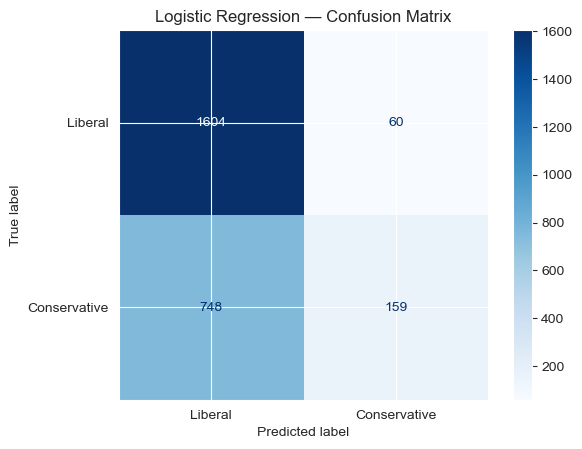

In [77]:
# Fit BERTopic with full probability matrix
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

# Evaluate with 5-fold CV AUC
X = np.array(probs)                     # shape: (n_docs, n_topics)
clf = LogisticRegression(max_iter=1000)
auc_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}") # better than accuracy metric because our classes are imbalanced

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Liberal","Conservative"]))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Liberal","Conservative"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [60]:
# number of topics
n_topics = len(topic_model.get_topic_info()) - 1 # subtract 1 because get_topic_info() includes the “-1” outlier row
print(f"Brettopic found {n_topics} topics in the corpus.")

Brettopic found 198 topics in the corpus.


In [62]:
# Find top-skew topics per class
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df["class"] = y.values
mean_by_class = probs_df.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]

top_cons = diff.nlargest(5).index.tolist()
top_lib  = diff.nsmallest(5).index.tolist()

print("Top Conservative topics:", top_cons)
print("Top Liberal topics:     ", top_lib)

for tid in top_cons:
    print(f"\n=== Topic {tid} (Conservative) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

for tid in top_lib:
    print(f"\n=== Topic {tid} (Liberal) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

Top Conservative topics: [0, 4, 6, 19, 42]
Top Liberal topics:      [1, 5, 10, 57, 156]

=== Topic 0 (Conservative) ===
  ukraine         0.0382
  russia          0.0310
  putin           0.0289
  russian         0.0259
  invasion        0.0206
  ukrainian       0.0182
  nato            0.0159
  invade          0.0154
  sanction        0.0117
  war             0.0116

=== Topic 4 (Conservative) ===
  trudeau         0.0848
  convoy          0.0700
  canada          0.0683
  trucker         0.0582
  canadian        0.0552
  emergency       0.0395
  justin          0.0360
  freedom         0.0328
  protest         0.0307
  bank            0.0292

=== Topic 6 (Conservative) ===
  anarcho         0.2109
  anarchism       0.0968
  anarchist       0.0782
  capitalist      0.0581
  capitalism      0.0580
  anarchy         0.0524
  anarchocapitalism 0.0358
  anarchocapitalist 0.0301
  difference      0.0215
  society         0.0202

=== Topic 19 (Conservative) ===
  inflation       0.2056
  pr

In [63]:
# Raw n-gram vocabulary comparison
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), max_features=5000)
X_cv = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

vocab_df = pd.DataFrame(X_cv.toarray(), columns=vocab)
vocab_df["class"] = y.values
counts = vocab_df.groupby("class").sum()

print("\nTop 20 terms (Liberal):")
print(counts.loc[0].nlargest(20), "\n")
print("Top 20 terms (Conservative):")
print(counts.loc[1].nlargest(20))


Top 20 terms (Liberal):
trump        557
biden        397
right        357
new          324
worker       310
woman        307
people       299
say          279
state        240
election     231
year         229
social       225
war          218
socialist    213
party        209
democracy    188
work         188
america      180
ukraine      175
communist    173
Name: 0, dtype: int64 

Top 20 terms (Conservative):
trump          507
biden          426
ukraine        358
capitalism     261
russia         253
putin          197
say            175
people         173
russian        138
state          138
new            133
desantis       132
government     123
libertarian    120
war            116
poll           115
president      115
right          114
think          102
year            99
Name: 1, dtype: int64
